In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
df = pd.read_csv("../data/raw/raw_data.csv")
print("Shape:", df.shape)
print("\nColumn names:")
for col in df.columns:
    print(col)

FileNotFoundError: [Errno 2] No such file or directory: 'pakistan_air_quality_final_clean'

In [3]:
print("AQI Categories:")
print(df['aqi_category'].value_counts())

print("\nCities:")
print(df['city'].value_counts())

print("\nSeason values:")
print(df['season'].unique())

print("\nDate range:")
print("From:", df['timestamp'].min())
print("To:", df['timestamp'].max())

print("\nFirst few rows of key columns:")
print(df[['timestamp', 'city', 'pm2_5', 'aqi_category', 'season']].head(10))

print("\nAny nulls:")
print(df.isnull().sum().sum())

AQI Categories:
aqi_category
Unhealthy                         8766
Moderate                          4861
Unhealthy for Sensitive Groups    4199
Very Unhealthy                    2617
Good                               759
Hazardous                          638
Name: count, dtype: int64

Cities:
city
Faisalabad        2184
Islamabad         2184
Karachi           2184
Lahore            2184
Multan            2184
Peshawar          2184
Quetta            2184
Rahim Yar Khan    2184
Rawalpindi        2184
Sialkot           2184
Name: count, dtype: int64

Season values:
['Autumn' 'Winter']

Date range:
From: 2025-11-06 00:00:00
To: 2026-02-04 23:00:00

First few rows of key columns:
             timestamp        city  pm2_5 aqi_category  season
0  2025-11-06 00:00:00  Faisalabad   22.6     Moderate  Autumn
1  2025-11-06 01:00:00  Faisalabad   24.2     Moderate  Autumn
2  2025-11-06 02:00:00  Faisalabad   30.7     Moderate  Autumn
3  2025-11-06 03:00:00  Faisalabad   34.8     Moderate  Au

In [4]:
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

os.makedirs("../data/processed", exist_ok=True)

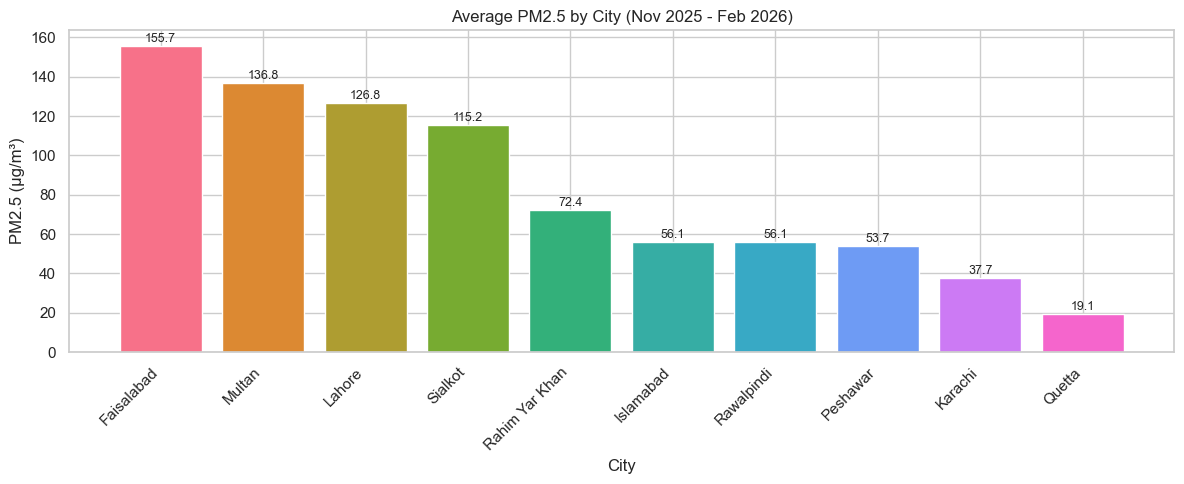

Most polluted city: Faisalabad
Least polluted city: Quetta


In [5]:
city_avg = df.groupby('city')['pm2_5'].mean().sort_values(ascending=False)

plt.figure()
bars = plt.bar(city_avg.index, city_avg.values, color=sns.color_palette("husl", len(city_avg)))
plt.title("Average PM2.5 by City (Nov 2025 - Feb 2026)")
plt.xlabel("City")
plt.ylabel("PM2.5 (μg/m³)")
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, city_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("../data/processed/chart_01_avg_pm25_by_city.png")
plt.show()
print("Most polluted city:", city_avg.index[0])
print("Least polluted city:", city_avg.index[-1])

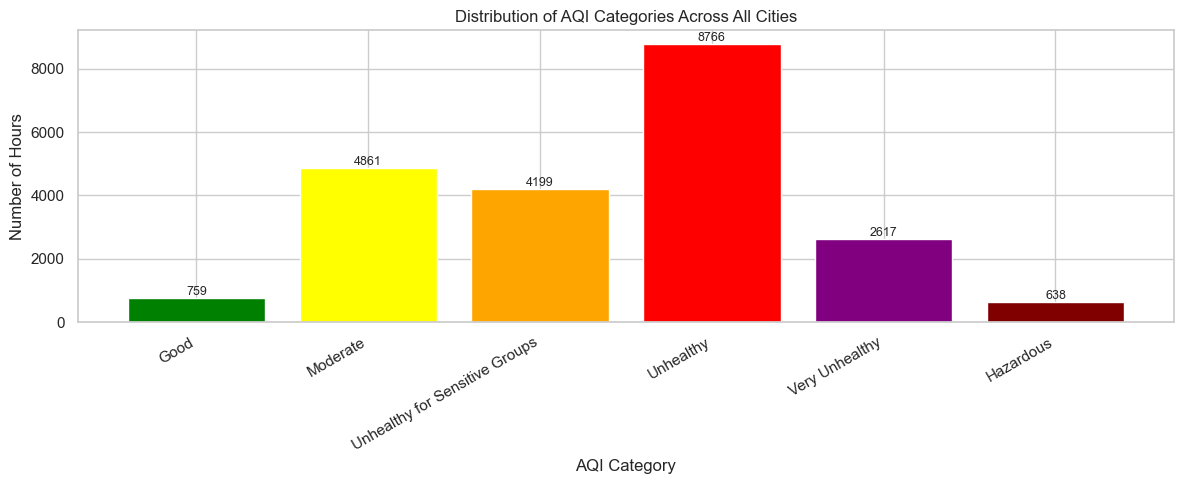

In [6]:
category_order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 
                  'Unhealthy', 'Very Unhealthy', 'Hazardous']
category_colors = ['green', 'yellow', 'orange', 'red', 'purple', 'maroon']

cat_counts = df['aqi_category'].value_counts().reindex(category_order)

plt.figure()
bars = plt.bar(cat_counts.index, cat_counts.values, color=category_colors)
plt.title("Distribution of AQI Categories Across All Cities")
plt.xlabel("AQI Category")
plt.ylabel("Number of Hours")
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, cat_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("../data/processed/chart_02_aqi_distribution.png")
plt.show()

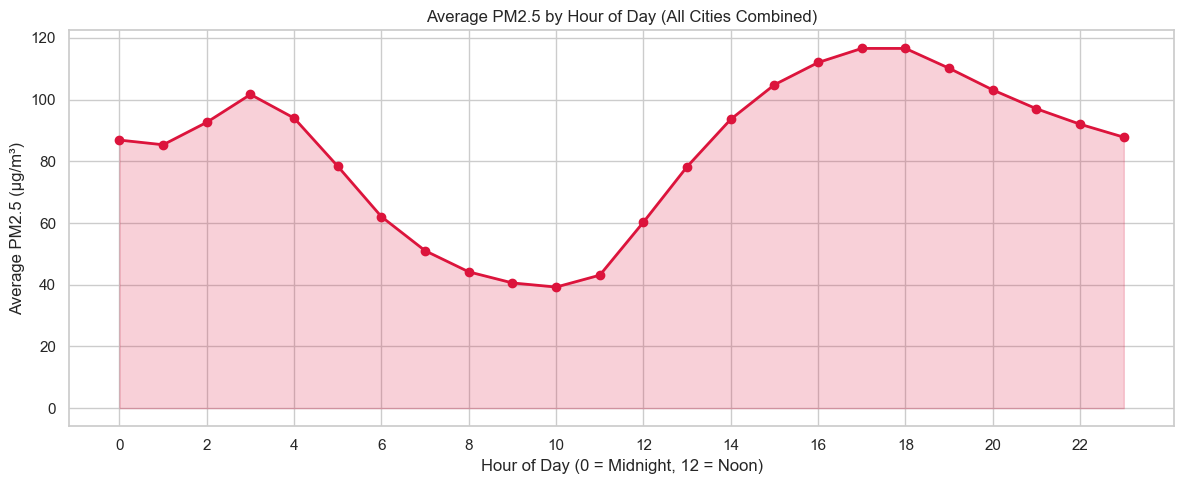

Peak pollution hour: 17:00


In [7]:
hourly = df.groupby('hour')['pm2_5'].mean()

plt.figure()
plt.plot(hourly.index, hourly.values, marker='o', linewidth=2, color='crimson')
plt.fill_between(hourly.index, hourly.values, alpha=0.2, color='crimson')
plt.title("Average PM2.5 by Hour of Day (All Cities Combined)")
plt.xlabel("Hour of Day (0 = Midnight, 12 = Noon)")
plt.ylabel("Average PM2.5 (μg/m³)")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig("../data/processed/chart_03_pm25_by_hour.png")
plt.show()
peak_hour = hourly.idxmax()
print(f"Peak pollution hour: {peak_hour}:00")

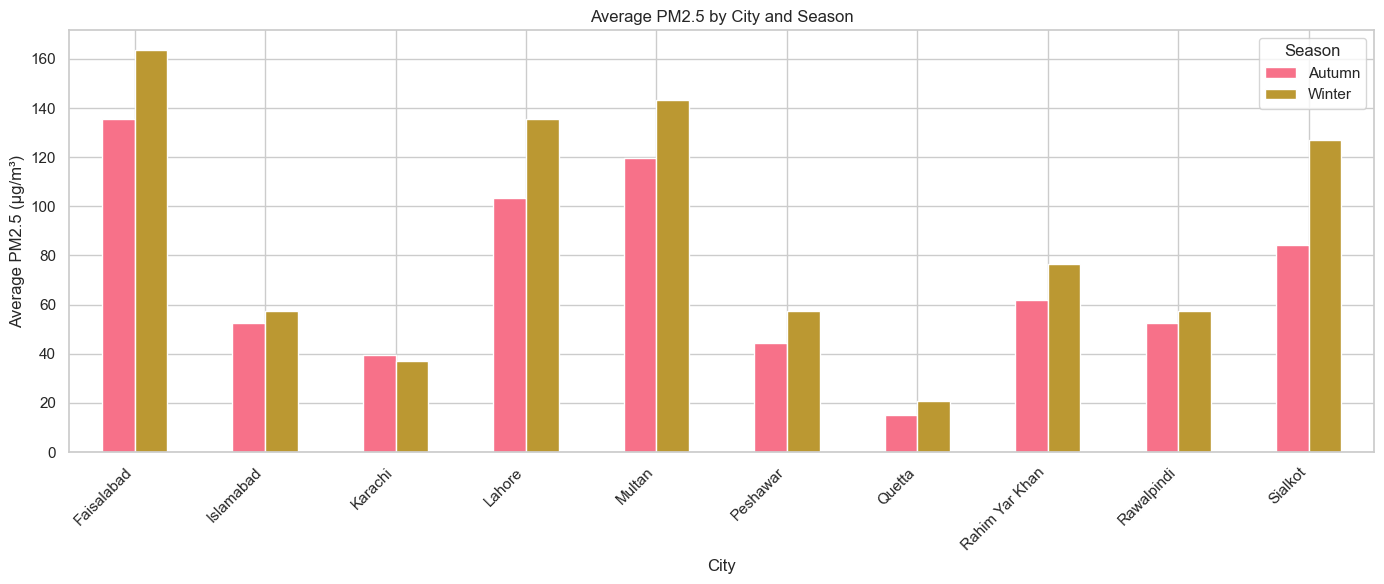

In [8]:
season_city = df.groupby(['city', 'season'])['pm2_5'].mean().unstack()

season_city.plot(kind='bar', figsize=(14, 6))
plt.title("Average PM2.5 by City and Season")
plt.xlabel("City")
plt.ylabel("Average PM2.5 (μg/m³)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Season")
plt.tight_layout()
plt.savefig("../data/processed/chart_04_pm25_by_season_city.png")
plt.show()

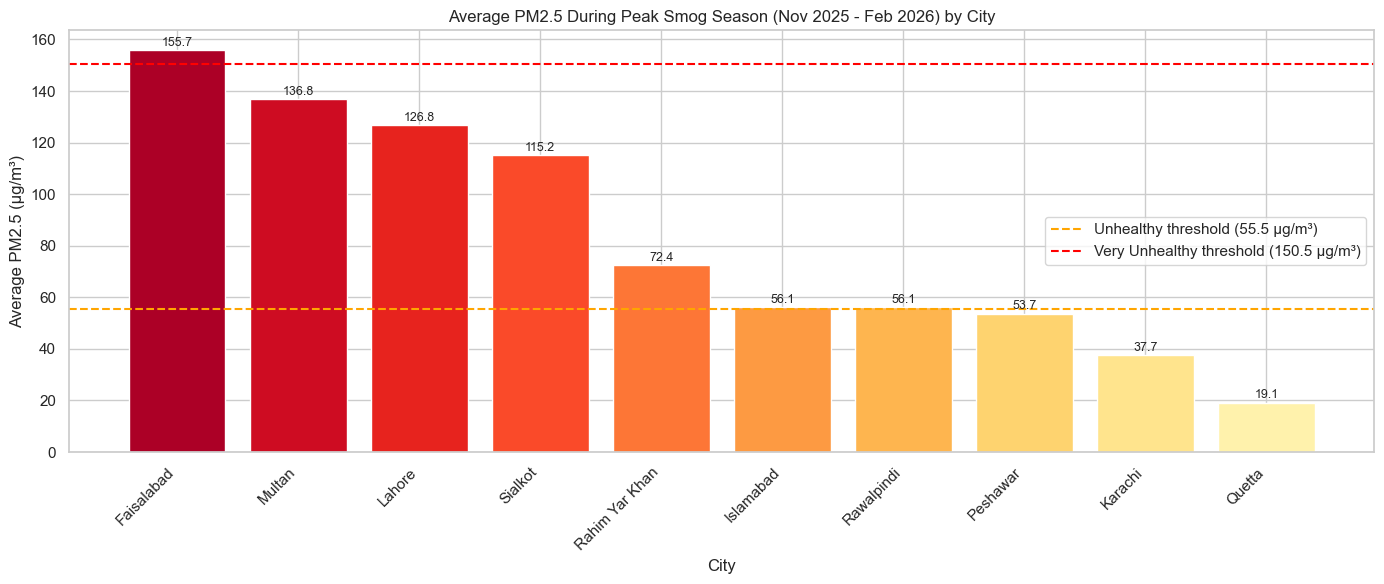

City PM2.5 rankings during smog season:
1. Faisalabad: 155.7 μg/m³ — ABOVE WHO annual limit
2. Multan: 136.8 μg/m³ — ABOVE WHO annual limit
3. Lahore: 126.8 μg/m³ — ABOVE WHO annual limit
4. Sialkot: 115.2 μg/m³ — ABOVE WHO annual limit
5. Rahim Yar Khan: 72.4 μg/m³ — ABOVE WHO annual limit
6. Islamabad: 56.1 μg/m³ — ABOVE WHO annual limit
7. Rawalpindi: 56.1 μg/m³ — ABOVE WHO annual limit
8. Peshawar: 53.7 μg/m³ — ABOVE WHO annual limit
9. Karachi: 37.7 μg/m³ — ABOVE WHO annual limit
10. Quetta: 19.1 μg/m³ — ABOVE WHO annual limit


In [16]:
city_avg_pm25 = df.groupby('city')['pm2_5'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
bars = plt.bar(city_avg_pm25.index, city_avg_pm25.values, 
               color=sns.color_palette("YlOrRd_r", len(city_avg_pm25)))
plt.axhline(y=55.5, color='orange', linestyle='--', linewidth=1.5, label='Unhealthy threshold (55.5 μg/m³)')
plt.axhline(y=150.5, color='red', linestyle='--', linewidth=1.5, label='Very Unhealthy threshold (150.5 μg/m³)')
plt.title("Average PM2.5 During Peak Smog Season (Nov 2025 - Feb 2026) by City")
plt.xlabel("City")
plt.ylabel("Average PM2.5 (μg/m³)")
plt.xticks(rotation=45, ha='right')
plt.legend()
for bar, val in zip(bars, city_avg_pm25.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("../data/processed/chart_05_smog_season_city_ranking.png")
plt.show()

print("City PM2.5 rankings during smog season:")
for i, (city, val) in enumerate(city_avg_pm25.items(), 1):
    who_limit = "ABOVE WHO annual limit" if val > 15 else "Within WHO limit"
    print(f"{i}. {city}: {val:.1f} μg/m³ — {who_limit}")

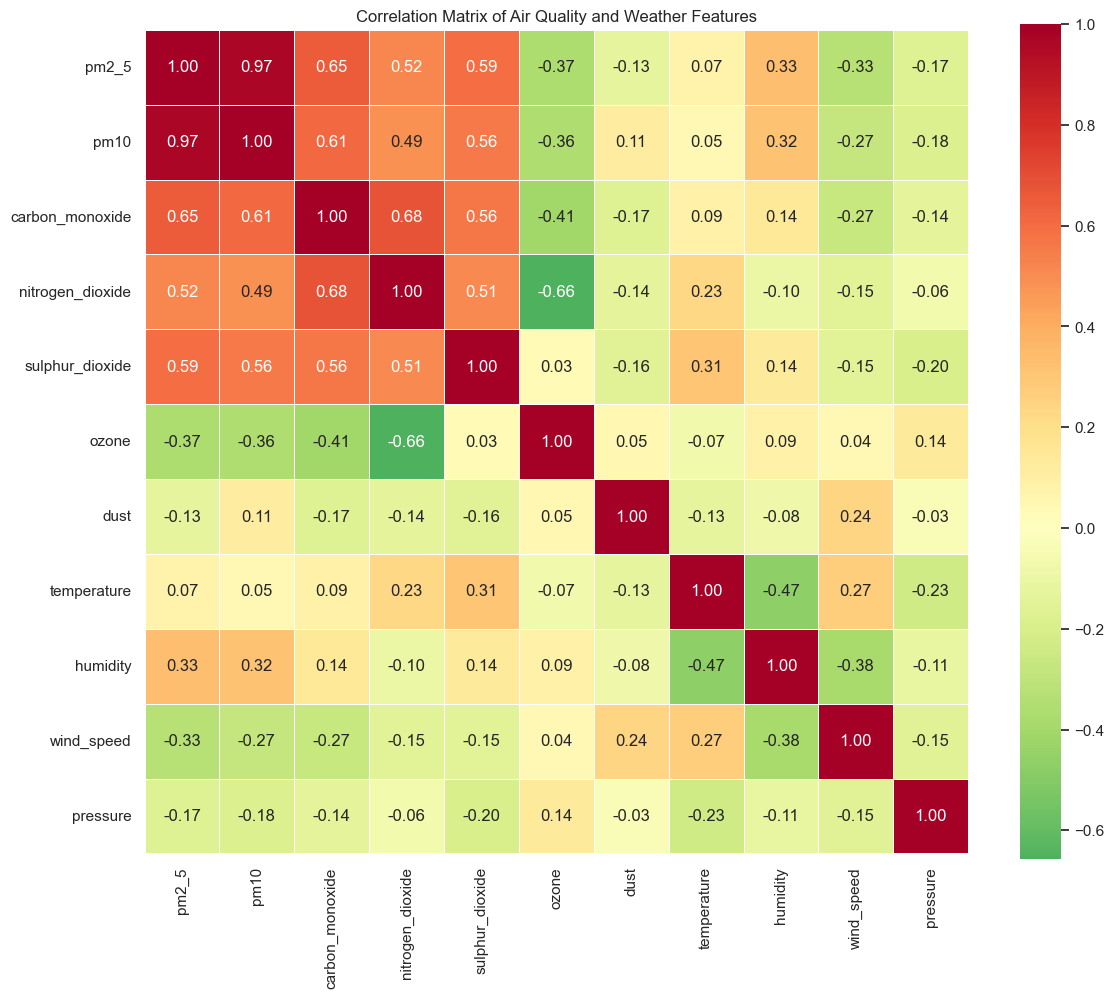

In [10]:
numeric_cols = ['pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 
                'sulphur_dioxide', 'ozone', 'dust', 'temperature', 
                'humidity', 'wind_speed', 'pressure']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            center=0, square=True, linewidths=0.5)
plt.title("Correlation Matrix of Air Quality and Weather Features")
plt.tight_layout()
plt.savefig("../data/processed/chart_06_correlation_heatmap.png")
plt.show()

<Figure size 1400x600 with 0 Axes>

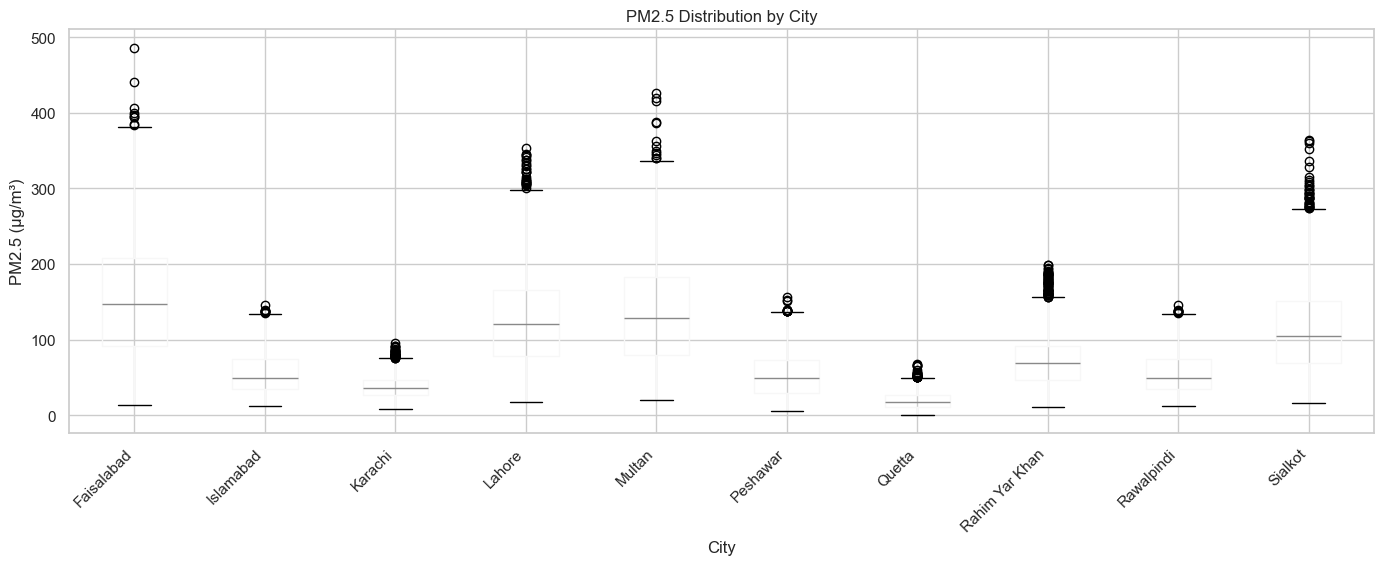

In [11]:
plt.figure(figsize=(14, 6))
df.boxplot(column='pm2_5', by='city', figsize=(14, 6))
plt.title("PM2.5 Distribution by City")
plt.suptitle("")
plt.xlabel("City")
plt.ylabel("PM2.5 (μg/m³)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../data/processed/chart_07_boxplot_pm25_city.png")
plt.show()

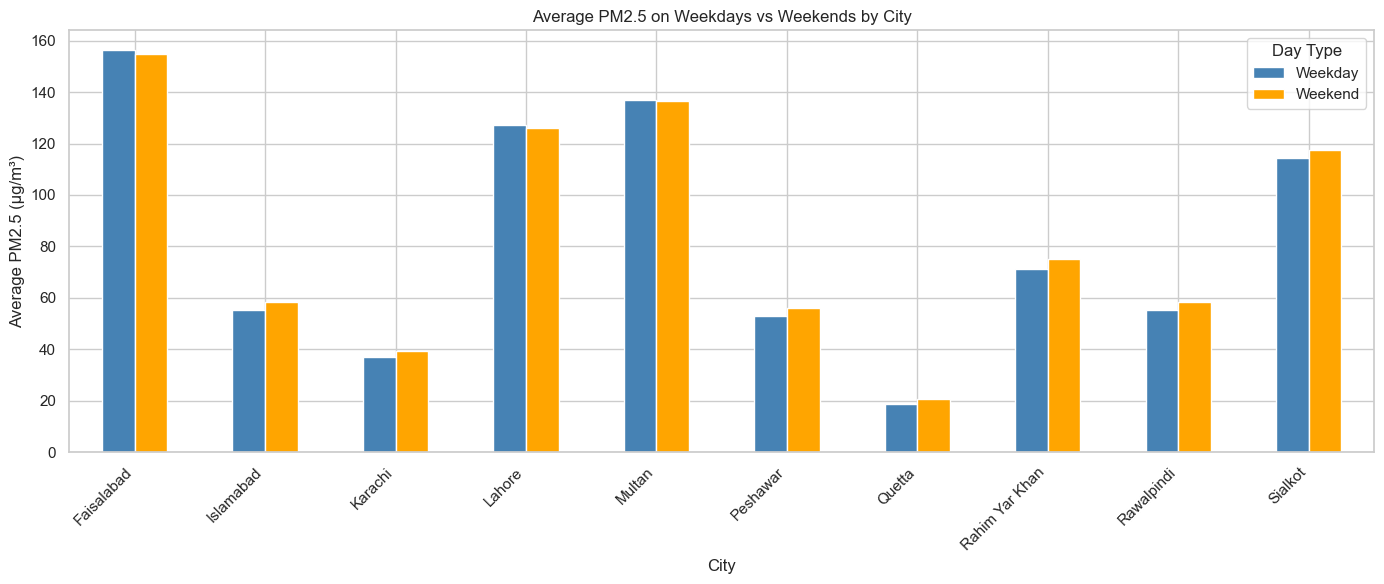

In [12]:
weekend_avg = df.groupby(['city', 'is_weekend'])['pm2_5'].mean().unstack()
weekend_avg.columns = ['Weekday', 'Weekend']

weekend_avg.plot(kind='bar', color=['steelblue', 'orange'], figsize=(14, 6))
plt.title("Average PM2.5 on Weekdays vs Weekends by City")
plt.xlabel("City")
plt.ylabel("Average PM2.5 (μg/m³)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Day Type")
plt.tight_layout()
plt.savefig("../data/processed/chart_08_weekend_vs_weekday.png")
plt.show()

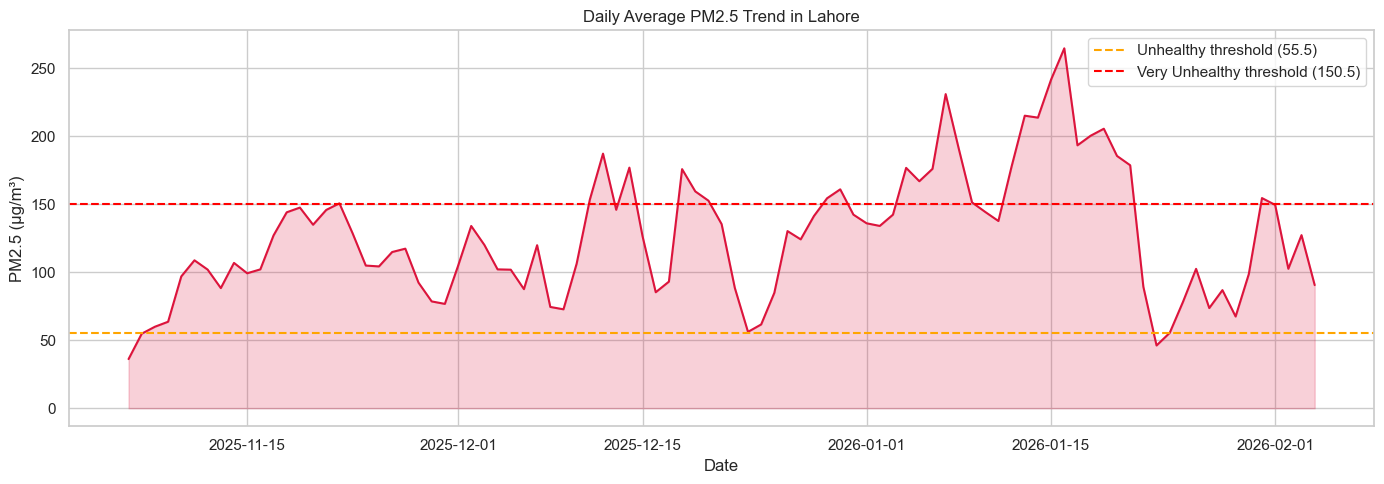

In [13]:
lahore = df[df['city'] == 'Lahore'].copy()
lahore['timestamp'] = pd.to_datetime(lahore['timestamp'])
lahore_daily = lahore.resample('D', on='timestamp')['pm2_5'].mean()

plt.figure(figsize=(14, 5))
plt.plot(lahore_daily.index, lahore_daily.values, color='crimson', linewidth=1.5)
plt.fill_between(lahore_daily.index, lahore_daily.values, alpha=0.2, color='crimson')
plt.axhline(y=55.5, color='orange', linestyle='--', label='Unhealthy threshold (55.5)')
plt.axhline(y=150.5, color='red', linestyle='--', label='Very Unhealthy threshold (150.5)')
plt.title("Daily Average PM2.5 Trend in Lahore")
plt.xlabel("Date")
plt.ylabel("PM2.5 (μg/m³)")
plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/chart_09_lahore_pm25_trend.png")
plt.show()

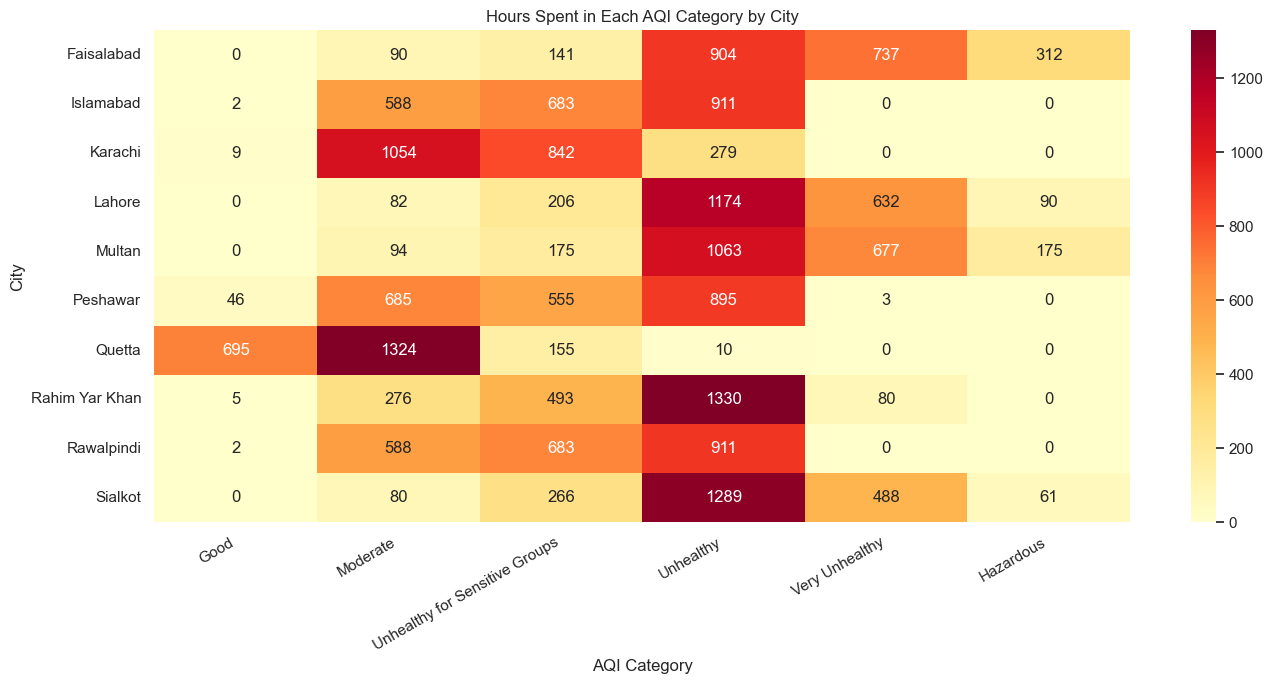

In [14]:
cat_city = df.groupby(['city', 'aqi_category']).size().unstack(fill_value=0)
cat_city = cat_city.reindex(columns=category_order)

plt.figure(figsize=(14, 7))
sns.heatmap(cat_city, annot=True, fmt='d', cmap='YlOrRd')
plt.title("Hours Spent in Each AQI Category by City")
plt.xlabel("AQI Category")
plt.ylabel("City")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("../data/processed/chart_10_aqi_category_by_city.png")
plt.show()

In [1]:
df_processed = df.copy()

category_mapping = {
    'Good': 'Good',
    'Moderate': 'Moderate',
    'Unhealthy for Sensitive Groups': 'Unhealthy',
    'Unhealthy': 'Unhealthy',
    'Very Unhealthy': 'Hazardous',
    'Hazardous': 'Hazardous'
}

df_processed['health_risk'] = df_processed['aqi_category'].map(category_mapping)

print("Health risk distribution:")
print(df_processed['health_risk'].value_counts())

df_processed.to_csv("../data/processed/processed_data.csv", index=False)
print("\nProcessed data saved to data/processed/processed_data.csv")
print("Shape:", df_processed.shape)

NameError: name 'df' is not defined